# Tutorial for spatial neighborhood analysis (SNA) & spatial co-localization score (sCLS) using 10X public data

**Author:**  
**Jun Inamo**  
_Computational Omics and Systems Immunology (COSI) Lab_  
_Division of Rheumatology and Center for Health AI_  
_University of Colorado School of Medicine, CO, USA_  
📧 jun.inamo@cuanschutz.edu

In [1]:
format(Sys.time(), '%d %B, %Y')

[1] "24 September, 2026"

In [2]:
library(Seurat)
library(magrittr)
library(dplyr)
# devtools::install_github("zhanghao-njmu/SCP")
library(SCP)
library(ggplot2)
library(circlize)
library(ComplexHeatmap)

if (file.exists("../DESCRIPTION")) devtools::load_all("..", quiet = TRUE) else library(spatialCooccur)

BuildSNNSeurat <- function (data.use, k.param = 30, prune.SNN = 1/15, nn.eps = 0) {
  my.knn <- nn2(data = data.use, k = k.param, searchtype = "standard", eps = nn.eps)
  nn.ranked <- my.knn$nn.idx
  
  snn_res <- ComputeSNN(nn_ranked = nn.ranked, prune = prune.SNN)
  rownames(snn_res) <- row.names(data.use)
  colnames(snn_res) <- row.names(data.use)
  return(snn_res)
}
environment(BuildSNNSeurat) <- asNamespace("Seurat")

# folder with the 10x example datasets (set XENIUM_SAMPLE_DIR to override)
data_dir <- Sys.getenv("XENIUM_SAMPLE_DIR", "./../10X_Xenium_sample")

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”


Loading required package: SeuratObject



Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”


Loading required package: sp




Attaching package: ‘SeuratObject’




...

Loading required package: grid



ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




Loading spatialCooccur v0.99.2: An R package for analyzing spatial co-occurrence.



To cite this package in publications, please use:
  Inamo J, et al. (2026). Spatial transcriptomics reveals  immune-stromal crosstalk within the synovium of patients with  juvenile idiopathic arthritis. JCI Insight. 11(1):e198074.  doi:10.1172/jci.insight.198074



Developed by: Jun Inamo <juninamo@keio.jp>



# Xenium Human Breast Gene Expression


## Preprocessing & Cell annotation

In [3]:

path <- paste0(data_dir, "/Xenium_V1_human_Breast_2fov_outs/")
data_name = stringr::str_split(path, "/")[[1]][length(stringr::str_split(path, "/")[[1]])-1]

# Load the Xenium data
data <- ReadXenium(path, outs = c("matrix", "microns"), type = c("centroids", "segmentations"))
## continue the regular LoadXenium
segmentations.data <- list(
  centroids = CreateCentroids(data$centroids),
  segmentation = CreateSegmentation(data$segmentations))
coords <- CreateFOV(
  coords = segmentations.data, 
  type = c("segmentation", "centroids"), 
  molecules = data$microns, 
  assay = "Spatial")
xenium.obj <- CreateSeuratObject(
  counts = data$matrix[["Gene Expression"]], 
  assay = "Spatial")
xenium.obj[["BlankCodeword"]] <- CreateAssayObject(counts = data$matrix[["Unassigned Codeword"]])
xenium.obj[["ControlCodeword"]] <- CreateAssayObject(counts = data$matrix[["Negative Control Codeword"]])
xenium.obj[["ControlProbe"]] <- CreateAssayObject(counts = data$matrix[["Negative Control Probe"]])
xenium.obj[["fov"]] <- coords
rm(data); gc(); gc()

Genome matrix has multiple modalities, returning a list of matrices for this genome



Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,12939514,691.1,19692738,1051.8,NA,19692738,1051.8
Vcells,27085989,206.7,45754539,349.1,204800,45712823,348.8


,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,12945910,691.4,19692738,1051.8,NA,19692738,1051.8
Vcells,27100299,206.8,45754539,349.1,204800,45712823,348.8


Warning message:
“Not validating FOV objects”


Warning message:
“Not validating Centroids objects”


Warning message:
“Not validating Centroids objects”


Warning message:
“Not validating FOV objects”


Warning message:
“Not validating Centroids objects”


...

5 x 5 sparse Matrix of class "dgCMatrix"
       aaaiikim-1 aaaljapa-1 aabhbgmg-1 aabpgobe-1 aacemgol-1
ABCC11          .          .          .          .          .
ACTA2           1          .          .          .          .
ACTG2           .          .          .          .          .
ADAM9           1          .          2          1          .
ADGRE5          .          .          .          .          .

,orig.ident,nCount_Spatial,nFeature_Spatial,nCount_BlankCodeword,nFeature_BlankCodeword,nCount_ControlCodeword,nFeature_ControlCodeword,nCount_ControlProbe,nFeature_ControlProbe
,<fct>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>
aaaiikim-1,SeuratProject,66,32,0,0,0,0,0,0
aaaljapa-1,SeuratProject,95,43,0,0,0,0,0,0
aabhbgmg-1,SeuratProject,215,74,0,0,0,0,0,0
aabpgobe-1,SeuratProject,103,42,0,0,0,0,0,0
aacemgol-1,SeuratProject,95,49,0,0,0,0,0,0
aacnljfi-1,SeuratProject,146,56,0,0,0,0,0,0


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    1.0    54.0   109.0   123.3   174.0   673.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00   31.00   46.00   44.66   59.00  112.00 

Warning message:
“Default search for "data" layer in "Spatial" assay yielded no results; utilizing "counts" layer instead.”


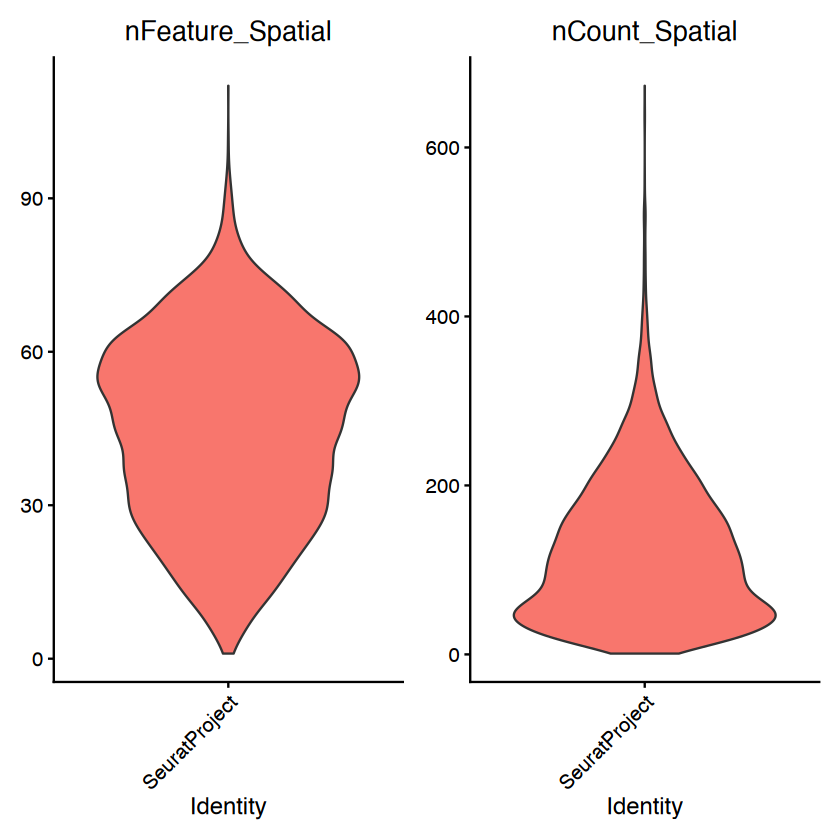

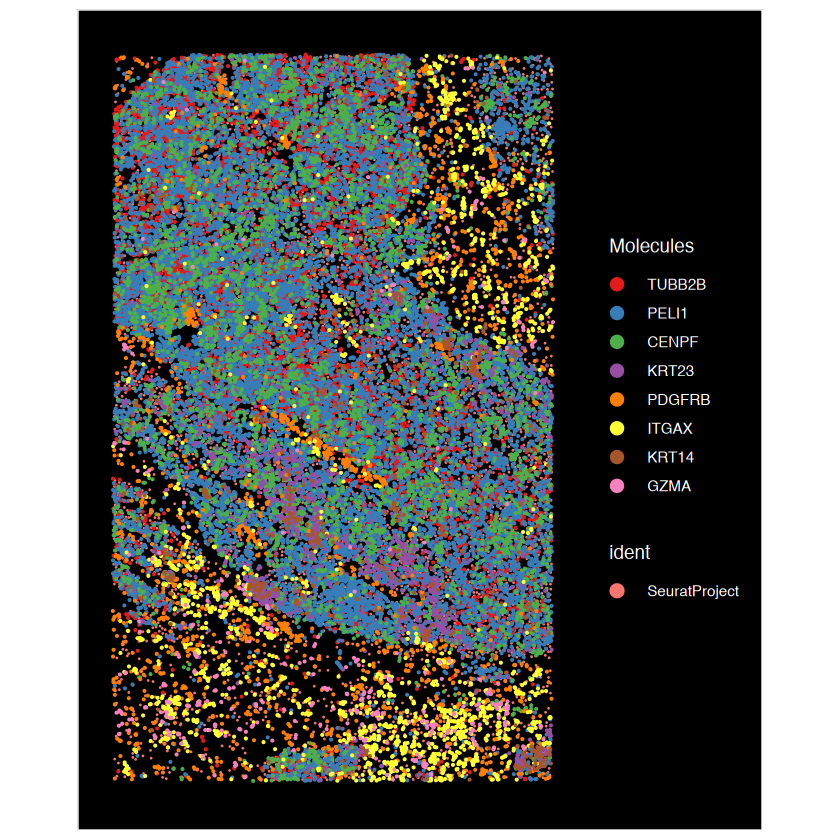

In [4]:

xenium.obj <- subset(xenium.obj, subset = nCount_Spatial > 0)

print(dim(xenium.obj@assays$Spatial$counts))
xenium.obj@assays$Spatial$counts[1:5,1:5]
head(xenium.obj@meta.data)
summary(xenium.obj@meta.data$nCount_Spatial)
summary(xenium.obj@meta.data$nFeature_Spatial)

VlnPlot(xenium.obj, features = c("nFeature_Spatial", "nCount_Spatial"), ncol = 2, pt.size = 0)

ImageDimPlot(xenium.obj, fov = "fov", molecules = c("TUBB2B", "PELI1", "CENPF", "KRT23","PDGFRB","ITGAX","KRT14","GZMA"), nmols = 20000)

In [5]:

xenium.obj <- SCTransform(xenium.obj, assay = "Spatial",
                          conserve.memory = TRUE, vst.flavor="v2")
xenium.obj <- RunPCA(xenium.obj, assay = "SCT", verbose = FALSE)
xenium.obj <- FindNeighbors(xenium.obj, 
                     reduction = "pca", 
                     k.param = 30,
                     dims = 1:30)
xenium.obj <- RunUMAP(xenium.obj, 
               reduction = "pca", 
               n.neighbors = 30L,
               min.dist = 0.3,
               dims = 1:30)

print("Clustering...")
snn_pcs <- BuildSNNSeurat(xenium.obj[["pca"]]@cell.embeddings[,1:30], 
                          nn.eps = 0)

resolution_list <- c(0.2, 0.4, 0.6, 0.8, 1.0)
ids_cos <- Reduce(cbind, parallel::mclapply(resolution_list, function(res_use) {
  Seurat:::RunModularityClustering(SNN = snn_pcs, 
                                   modularity = 1, 
                                   resolution = res_use, 
                                   algorithm = 3, 
                                   n.start = 10, 
                                   n.iter = 10, random.seed = 0, print.output = FALSE, 
                                   temp.file.location = NULL, edge.file.name = NULL)    
}, mc.cores = min(16, length(resolution_list))))
ids_cos %<>% data.frame()
colnames(ids_cos) <- sprintf("res_%.2f", resolution_list)

ids_cos$res_0.20 <- as.character(ids_cos$res_0.20)
ids_cos$res_0.40 <- as.character(ids_cos$res_0.40)
ids_cos$res_0.60 <- as.character(ids_cos$res_0.60)
ids_cos$res_0.80 <- as.character(ids_cos$res_0.80)
ids_cos$res_1.00 <- as.character(ids_cos$res_1.00)

rownames(ids_cos) = rownames(xenium.obj@meta.data)
ids_cos <- ids_cos %>%
  dplyr::mutate(across(everything(), ~ factor(.x, levels = sort(unique(.x)))))
xenium.obj <- AddMetaData(xenium.obj, ids_cos)
head(xenium.obj@meta.data)


resolution = "0.60"
Idents(xenium.obj) = xenium.obj@meta.data[,paste0("res_",resolution)]

cluster_col = paste0("res_",resolution)

Running SCTransform on assay: Spatial



Running SCTransform on layer: counts



vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.



Variance stabilizing transformation of count matrix of size 280 by 7273



Model formula is y ~ log_umi



...

12:22:39 Initializing from normalized Laplacian + noise (using RSpectra)



12:22:39 Commencing optimization for 500 epochs, with 319794 positive edges



12:22:44 Optimization finished



[1] "Clustering..."


,orig.ident,nCount_Spatial,nFeature_Spatial,nCount_BlankCodeword,nFeature_BlankCodeword,nCount_ControlCodeword,nFeature_ControlCodeword,nCount_ControlProbe,nFeature_ControlProbe,nCount_SCT,nFeature_SCT,res_0.20,res_0.40,res_0.60,res_0.80,res_1.00
,<fct>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>
aaaiikim-1,SeuratProject,66,32,0,0,0,0,0,0,112,33,0,0,0,0,2
aaaljapa-1,SeuratProject,95,43,0,0,0,0,0,0,107,43,0,0,0,0,2
aabhbgmg-1,SeuratProject,215,74,0,0,0,0,0,0,139,69,0,0,0,0,2
aabpgobe-1,SeuratProject,103,42,0,0,0,0,0,0,111,42,0,0,0,0,2
aacemgol-1,SeuratProject,95,49,0,0,0,0,0,0,106,49,0,2,2,0,0
aacnljfi-1,SeuratProject,146,56,0,0,0,0,0,0,132,56,0,0,0,0,2


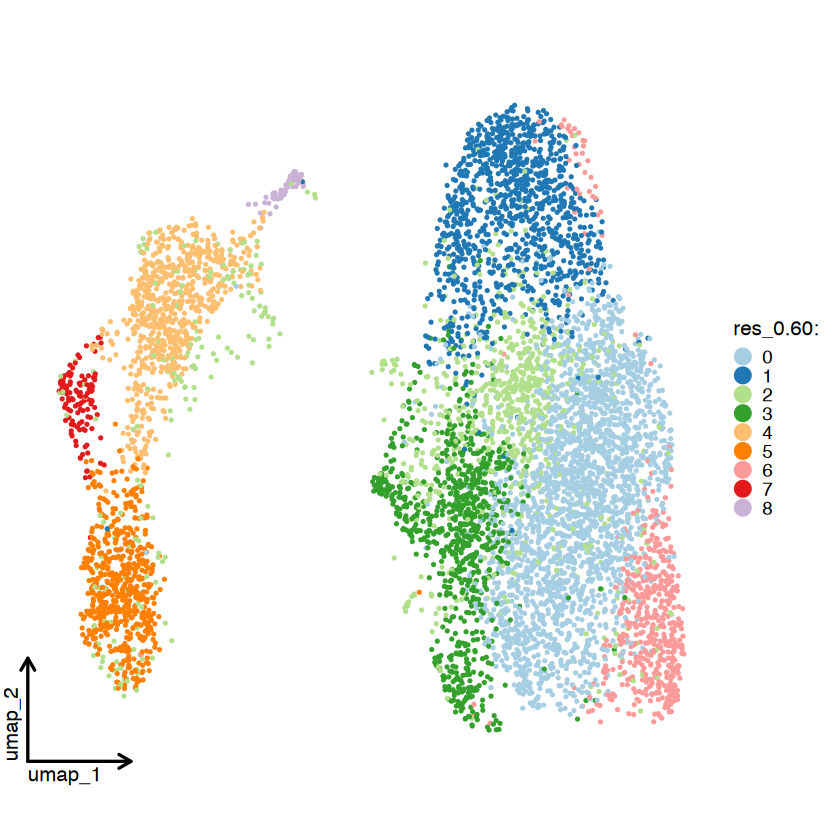

In [6]:
g = CellDimPlot(
  srt = xenium.obj, 
  group.by = cluster_col, 
  reduction = "UMAP", theme_use = "theme_blank",
  raster = FALSE,
  stat_plot_size = 3
) 
g 

In [7]:
xenium.obj.markers <- FindAllMarkers(xenium.obj, only.pos = TRUE)
xenium.obj.markers %>%
  group_by(cluster) %>%
  dplyr::slice_max(avg_log2FC, n = 10) %>%
  as.data.frame() 

Calculating cluster 0



Calculating cluster 1



Calculating cluster 2



Calculating cluster 3



Calculating cluster 4



Calculating cluster 5



Calculating cluster 6



Calculating cluster 7



Calculating cluster 8



p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
4.352502e-144,1.1070971,0.631,0.312,1.218701e-141,0,TUBB2B
2.107105e-198,1.0848830,0.844,0.560,5.899895e-196,0,CCND1
7.158840e-12,1.0142743,0.063,0.029,2.004475e-09,0,SERHL2
1.120600e-69,0.9176133,0.440,0.236,3.137681e-67,0,TRAF4
1.399719e-34,0.8642718,0.254,0.137,3.919212e-32,0,MYBPC1
1.514970e-30,0.8518701,0.227,0.122,4.241917e-28,0,PTRHD1
2.436247e-80,0.8189955,0.584,0.349,6.821490e-78,0,SLC5A6
3.880890e-109,0.7992065,0.784,0.553,1.086649e-106,0,SEC11C
8.794545e-198,0.7828638,0.959,0.823,2.462473e-195,0,TOMM7


Cluster annotation:
0	Basal-like epithelial cells / Myoepithelial cells
1	Proliferating epithelial cells
2	Basal/myoepithelial tumor cells
3	Unclassified immune-like cells
4	Inflammatory immune cells (e.g. B cells / monocytes)
5	Cancer-associated fibroblasts (CAFs)
6	Macrophages (TAMs)
7	Cytotoxic / Activated T cells
8	Endothelial cells

Clusters are named by marker-gene signatures (the signature with the highest average scaled expression), so the names do not depend on the arbitrary cluster numbering.

In [8]:
table(xenium.obj@meta.data[,cluster_col])
# Annotate clusters with marker signatures rather than fixed cluster numbers,
# so the labels stay correct if clustering changes between package versions.
signatures <- list(
  BasalMyo_epithelial_cells      = c("MYBPC1", "SERHL2", "CCND1", "TRAF4"),
  Proliferating_epithelial_cells = c("TOP2A", "MKI67", "CENPF", "PCLAF"),
  BasalMyo_tumor_cells           = c("KRT5", "KRT14", "KRT23", "KLF5"),
  Luminal_tumor_cells            = c("ESR1", "FOXA1", "GATA3", "KRT8", "CEACAM6"),
  Cytotoxic_T                    = c("CD3E", "PRF1", "GZMA", "TRAC", "CD247", "CD8A"),
  `B_and_plasma_cells`           = c("MS4A1", "CD79A", "MZB1"),
  `Tumor-associated_macrophages` = c("CD163", "C1QA", "CD68", "ITGAX", "LYZ"),
  `Cancer-associated_fibroblasts`= c("POSTN", "LUM", "PDGFRB", "SFRP4", "FBLN1", "DPT", "MMP2"),
  Endothelial_cells              = c("VWF", "CLEC14A", "KDR", "MMRN2"),
  Mast_cells                     = c("CPA3", "TPSAB1", "KIT")
)
feats <- intersect(unique(unlist(signatures)), rownames(xenium.obj))
avg <- as.matrix(AverageExpression(xenium.obj, assays = "SCT", features = feats,
                                   group.by = cluster_col, layer = "data")$SCT)
colnames(avg) <- sub("^g", "", colnames(avg))
avg <- t(scale(t(avg))); avg[is.na(avg)] <- 0          # z-score each gene across clusters
sig_score <- sapply(signatures, function(g) colMeans(avg[intersect(g, rownames(avg)), , drop = FALSE]))
best <- setNames(colnames(sig_score)[max.col(sig_score, ties.method = "first")], rownames(sig_score))
round(sig_score, 2)
best
xenium.obj@meta.data$new_cluster <- unname(best[as.character(xenium.obj@meta.data[, cluster_col])])
table(xenium.obj@meta.data$new_cluster)
cluster_col = "new_cluster"
Idents(xenium.obj) = xenium.obj@meta.data$new_cluster


   0    1    2    3    4    5    6    7    8 
2389 1079  956  854  700  575  529  122   69 

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.


First group.by variable `res_0.60` starts with a number, appending `g` to ensure valid variable names
This message is displayed once every 8 hours.


,BasalMyo_epithelial_cells,Proliferating_epithelial_cells,BasalMyo_tumor_cells,Luminal_tumor_cells,Cytotoxic_T,B_and_plasma_cells,Tumor-associated_macrophages,Cancer-associated_fibroblasts,Endothelial_cells,Mast_cells
0,1.46,-0.09,-0.25,-0.03,-0.37,-0.28,-0.48,-0.62,-0.34,0.04
1,0.63,2.57,-0.10,0.15,-0.37,-0.30,-0.48,-0.60,-0.34,0.08
2,-0.01,-0.10,-0.01,-0.11,-0.35,-0.33,-0.40,-0.50,-0.33,0.07
3,0.88,-0.05,2.59,0.24,-0.37,-0.51,-0.45,-0.60,-0.34,0.38
4,-0.84,-0.62,-0.51,0.00,-0.26,1.36,-0.02,2.29,-0.30,-0.22
5,-0.99,-0.65,-0.49,0.15,-0.21,-0.18,2.59,0.00,-0.34,0.28
6,0.83,-0.08,-0.21,0.26,-0.37,-0.28,-0.48,-0.64,-0.35,-0.30
7,-1.16,-0.51,-0.55,0.36,2.66,1.22,0.14,0.23,-0.32,0.28
8,-0.81,-0.47,-0.46,-1.02,-0.35,-0.69,-0.42,0.45,2.67,-0.62


0                                1 
     "BasalMyo_epithelial_cells" "Proliferating_epithelial_cells" 
                               2                                3 
                    "Mast_cells"           "BasalMyo_tumor_cells" 
                               4                                5 
 "Cancer-associated_fibroblasts"   "Tumor-associated_macrophages" 
                               6                                7 
     "BasalMyo_epithelial_cells"                    "Cytotoxic_T" 
                               8 
             "Endothelial_cells"


     BasalMyo_epithelial_cells           BasalMyo_tumor_cells 
                          2918                            854 
 Cancer-associated_fibroblasts                    Cytotoxic_T 
                           700                            122 
             Endothelial_cells                     Mast_cells 
                            69                            956 
Proliferating_epithelial_cells   Tumor-associated_macrophages 
                          1079                            575 

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


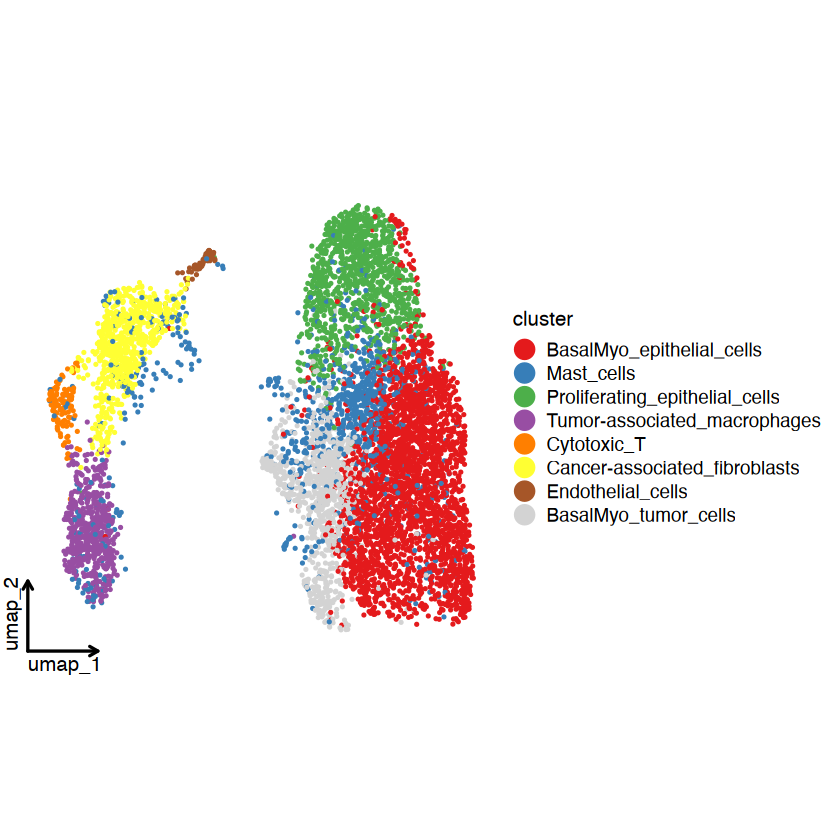

In [9]:
cluster_COLORS = manual_colors
names(cluster_COLORS) = levels(Idents(xenium.obj))
cluster_COLORS = na.omit(cluster_COLORS)
g = CellDimPlot(
  srt = xenium.obj, 
  group.by = cluster_col, 
  reduction = "UMAP", theme_use = "theme_blank",
  raster = FALSE,
  stat_plot_size = 1
) &
  scale_color_manual(values = cluster_COLORS) &
  guides(color = guide_legend(override.aes = list(size=5,
                                                 alpha = 1),
                             title = "cluster",
                             ncol = 1))
g 

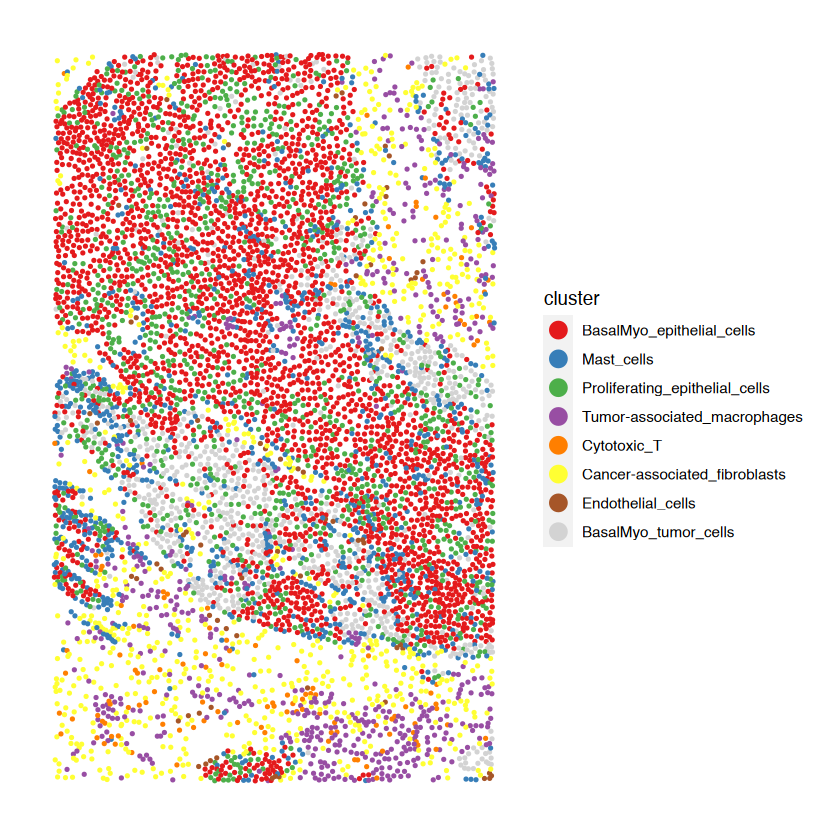

In [10]:
g = ImageDimPlot(xenium.obj,
             fov = "fov", 
             size = 1.2,
             group.by = cluster_col, 
             dark.background = F)  &
  scale_fill_manual(values = cluster_COLORS) &
  guides(fill = guide_legend(override.aes = list(size=5,
                                                 alpha = 1),
                             title = "cluster",
                             ncol = 1))
g 

## Spatial neighborhood analysis (SNA, cell type level analysis)

In [11]:
n_perm = 100
neighbors.k_ = 30 # Number of neighbors to search
seed = 1234

start_time = Sys.time()
xenium.obj <- nhood_enrichment.Seurat(
  xenium.obj,
  cluster_key = cluster_col, 
  neighbors.k = neighbors.k_, 
  connectivity_key = "nn", 
  transformation = TRUE,
  n_perms = n_perm, seed = seed, n_jobs = 4
)
end_time = Sys.time()
print("Elapsed time:")
difftime(end_time, start_time, units = "secs")

[1] "Elapsed time:"


Time difference of 2.019416 secs

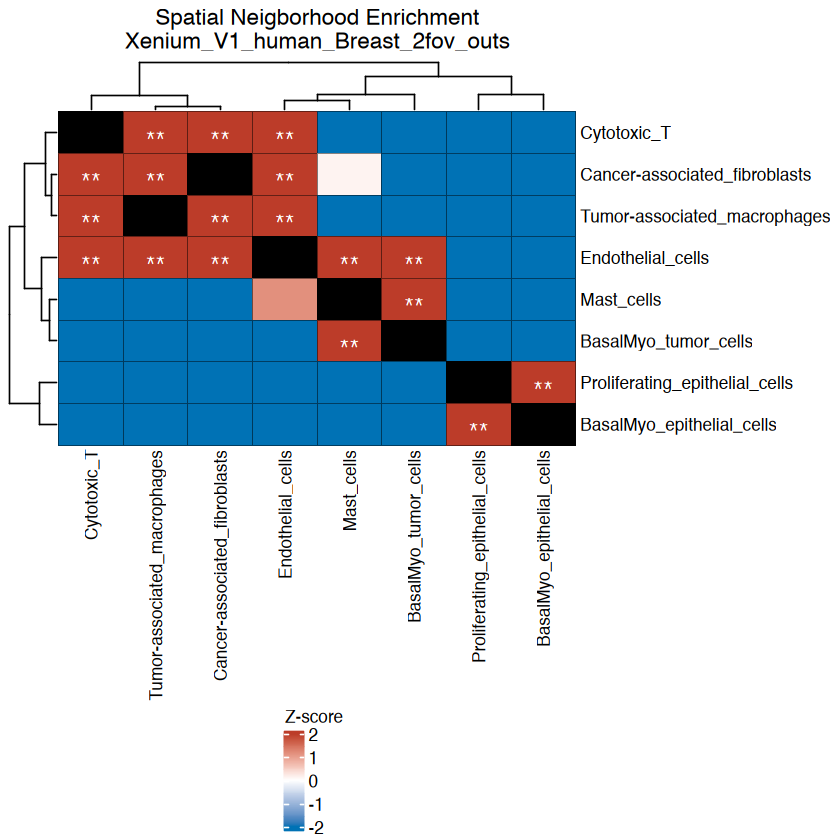

In [12]:
mat = xenium.obj@misc[[paste0(cluster_col,"_nhood_enrichment")]]$zscore
colnames(mat) = gsub("^Cluster","",colnames(mat))
rownames(mat) = gsub("^Cluster","",rownames(mat))

pval_mat <- 1 - pnorm(mat)
fdr_vec <- p.adjust(as.vector(pval_mat), method = "BH")
fdr_mat <- matrix(fdr_vec, nrow=nrow(mat), ncol=ncol(mat),
                  dimnames = dimnames(mat))
sig_mat <- ifelse(fdr_mat < 0.05, "**", ifelse(fdr_mat > 0.05 & fdr_mat < 0.1, "*", ""))

common_names <- intersect(rownames(mat), colnames(mat))
for (nm in common_names) {
  mat[nm, nm] <- NA
  sig_mat[nm, nm] <- ""
}

heatmap <- Heatmap(mat,
                   name = "Z-score",
                   col = colorRamp2(c(-2, 0, 2), c("#0072B5FF", "white", "#BC3C29FF")), 
                   show_row_names = TRUE, 
                   show_column_names = TRUE,  
                   cluster_rows = TRUE,  
                   cluster_columns = TRUE,  
                   #show_column_dend = FALSE,
                   #show_row_dend = FALSE,
                   row_title = "",  
                   column_title = paste0("Spatial Neigborhood Enrichment\n",data_name),
                   rect_gp = gpar(col = "black", lwd = 0.3),
                   na_col = "black",         
                   column_names_gp = grid::gpar(fontsize = 10),
                   row_names_gp = grid::gpar(fontsize = 10),

                   cell_fun = function(j, i, x, y, width, height, fill) {
                     if(sig_mat[i, j] == "**") {
                       grid.text("**", 
                                 x = x,
                                 y = y - 0.2 * height,  
                                 gp = gpar(fontsize = 15, col = "white", fontface = "bold"))
                     }
                     if(sig_mat[i, j] == "*") {
                       grid.text("*", 
                                 x = x,
                                 y = y - 0.2 * height, 
                                 gp = gpar(fontsize = 15, col = "white", fontface = "bold"))
                     }
                   }
)


draw(heatmap, 
     merge_legend = TRUE,
     heatmap_legend_side = "bottom", 
     annotation_legend_side = "bottom")


## Spatial co-localization score (sCLA, cell-cell level analysis)

In [13]:
xenium.obj[["fov"]]$centroids@coords

x,y
3.986221,342.61966
6.680080,353.63556
10.924507,344.44751
12.469139,326.37842
13.614200,336.31012
16.602362,292.55316
18.095470,307.78577
7.015532,306.04666
13.646845,299.77997
18.019503,317.56729


In [14]:

cluster_x <- "Cytotoxic_T"
cluster_y <- "Cancer-associated_fibroblasts"
table(Idents(xenium.obj))
radius_ = 30 # Radius to search for neighbors (µm, cell_type_2) around anchor cells (cell_type_1)

start_time = Sys.time()
cooccur_local_df <- cooccur_local.Seurat(
  xenium.obj,
  cluster_key      = cluster_col,
  sample_key       = "fov",
  cluster_x        = cluster_x,
  cluster_y        = cluster_y,
  connectivity_key = "nn",
  neighbors.k      = neighbors.k_, 
  radius           = radius_,
  maxnsteps        = 15
)
end_time = Sys.time()
print("Elapsed time:")
difftime(end_time, start_time, units = "secs")
summary(cooccur_local_df)


     BasalMyo_epithelial_cells                     Mast_cells 
                          2918                            956 
Proliferating_epithelial_cells   Tumor-associated_macrophages 
                          1079                            575 
                   Cytotoxic_T  Cancer-associated_fibroblasts 
                           122                            700 
             Endothelial_cells           BasalMyo_tumor_cells 
                            69                            854 

stopping after 4 steps



[1] "Elapsed time:"


Time difference of 1.44676 secs

 cooccur_local_Cytotoxic_T_Cancer-associated_fibroblasts
 Min.   :0.0000000                                      
 1st Qu.:0.0000000                                      
 Median :0.0000773                                      
 Mean   :0.1106833                                      
 3rd Qu.:0.0646834                                      
 Max.   :1.1785277                                      

Warning message:
“No FOV associated with assay 'SCT', using global default FOV”


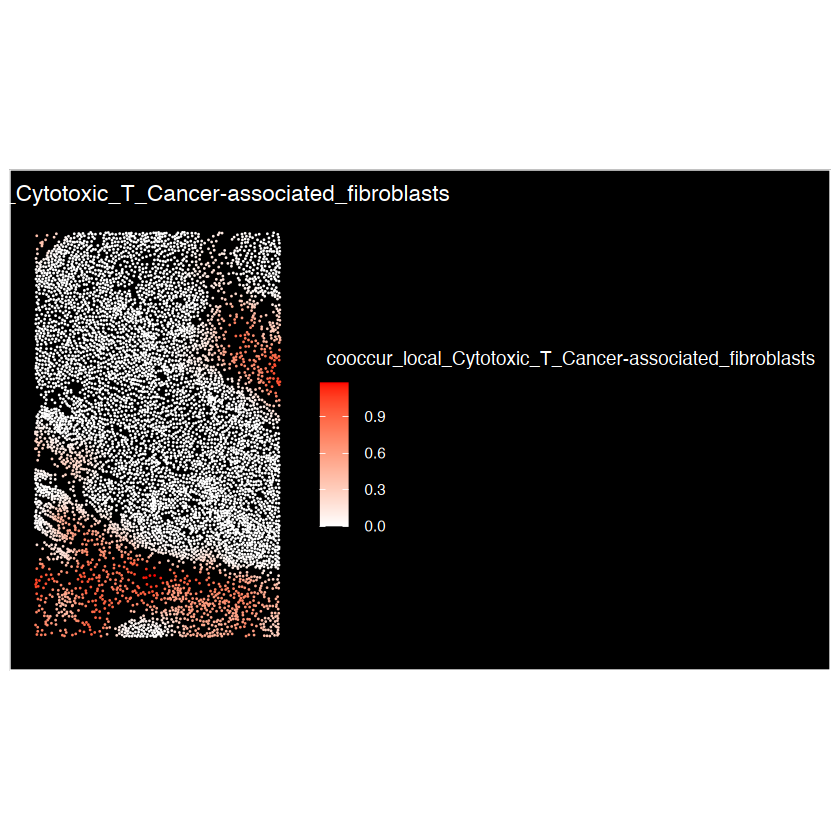

In [15]:
xenium.obj = AddMetaData(xenium.obj, cooccur_local_df)

g = ImageFeaturePlot(xenium.obj, 
                     features = paste0("cooccur_local_",cluster_x,"_",cluster_y), 
                     #dark.background = F,
                     cols = c("white", "red"))
g

# Xenium Mouse Brain

## Preprocessing & Cell annotation

Warning message:
“cells did not contain a segmentation_method column. Skipping...”


Genome matrix has multiple modalities, returning a list of matrices for this genome



Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


...

Warning message:
“Not validating FOV objects”


Warning message:
“Not validating FOV objects”


Warning message:
“Not validating FOV objects”


Warning message:
“Not validating Seurat objects”


Warning message:
“Default search for "data" layer in "Xenium" assay yielded no results; utilizing "counts" layer instead.”


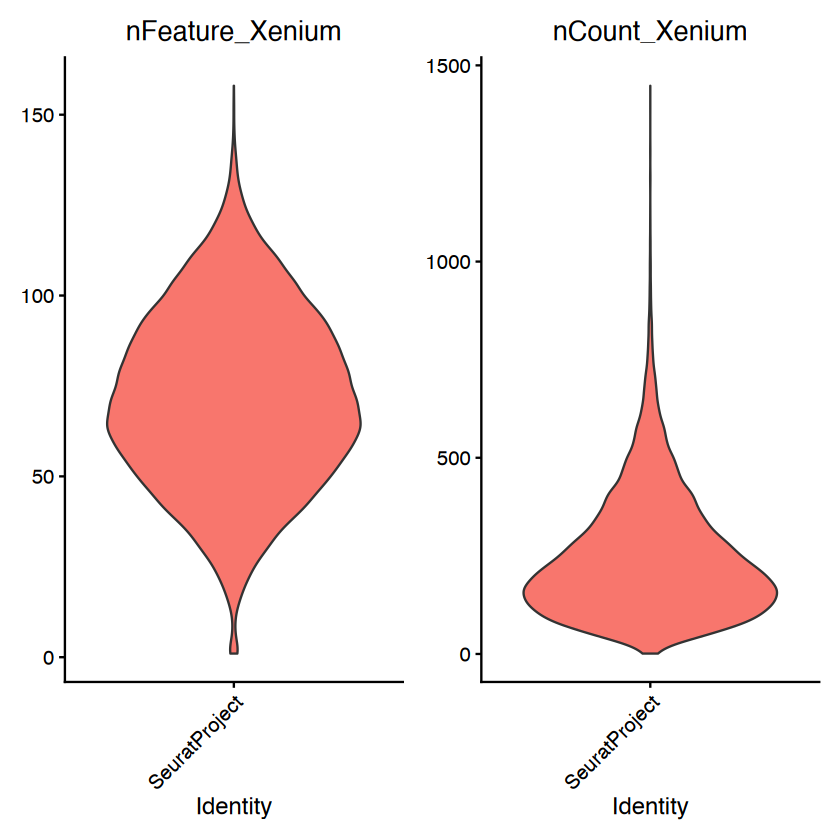

In [16]:
path <- paste0(data_dir, "/Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_outs/")
data_name = stringr::str_split(path, "/")[[1]][length(stringr::str_split(path, "/")[[1]])-1]

xenium.obj <- LoadXenium(path, fov = "fov")
# remove cells with 0 counts
xenium.obj <- subset(xenium.obj, subset = nCount_Xenium > 0)

VlnPlot(xenium.obj, features = c("nFeature_Xenium", "nCount_Xenium"), ncol = 2, pt.size = 0)

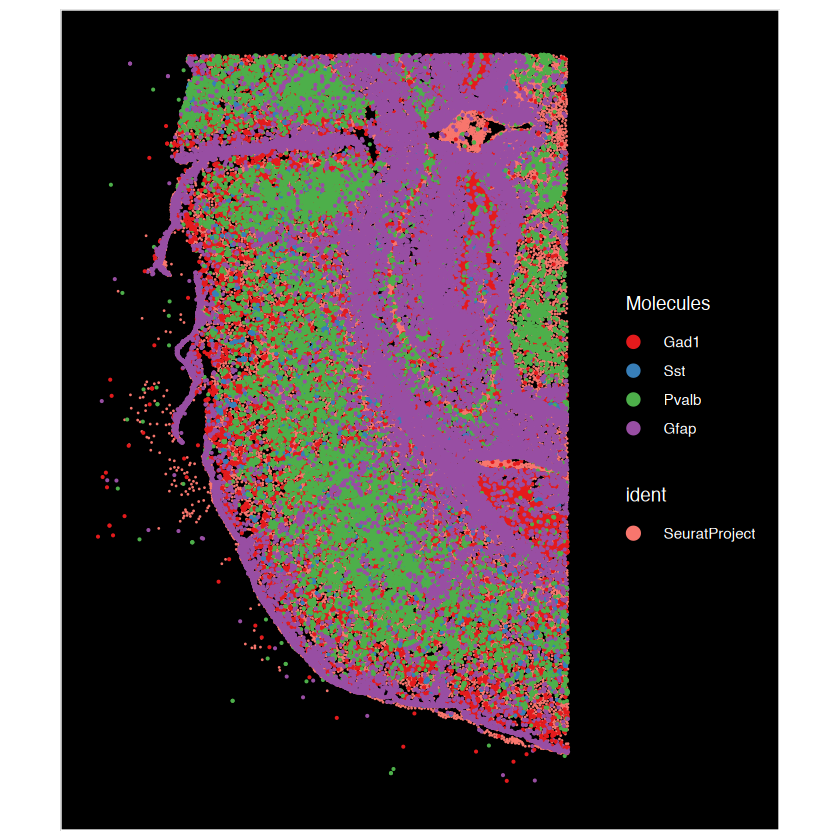

In [17]:
ImageDimPlot(xenium.obj, 
             fov = "fov", 
             size = 0.5,
             molecules = c("Gad1", "Sst", "Pvalb", "Gfap"), nmols = 20000)

In [18]:
xenium.obj <- SCTransform(xenium.obj, assay = "Xenium")
xenium.obj <- RunPCA(xenium.obj, npcs = 30, features = rownames(xenium.obj))
xenium.obj <- RunUMAP(xenium.obj, dims = 1:30)
xenium.obj <- FindNeighbors(xenium.obj, reduction = "pca", dims = 1:30)
xenium.obj <- FindClusters(xenium.obj, resolution = 0.3)

Running SCTransform on assay: Xenium



Running SCTransform on layer: counts



vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.



Variance stabilizing transformation of count matrix of size 248 by 36553



Model formula is y ~ log_umi



...

12:24:48 Commencing optimization for 200 epochs, with 1669102 positive edges



12:24:57 Optimization finished



Computing nearest neighbor graph



Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 36553
Number of edges: 1340944

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9585
Number of communities: 27
Elapsed time: 4 seconds


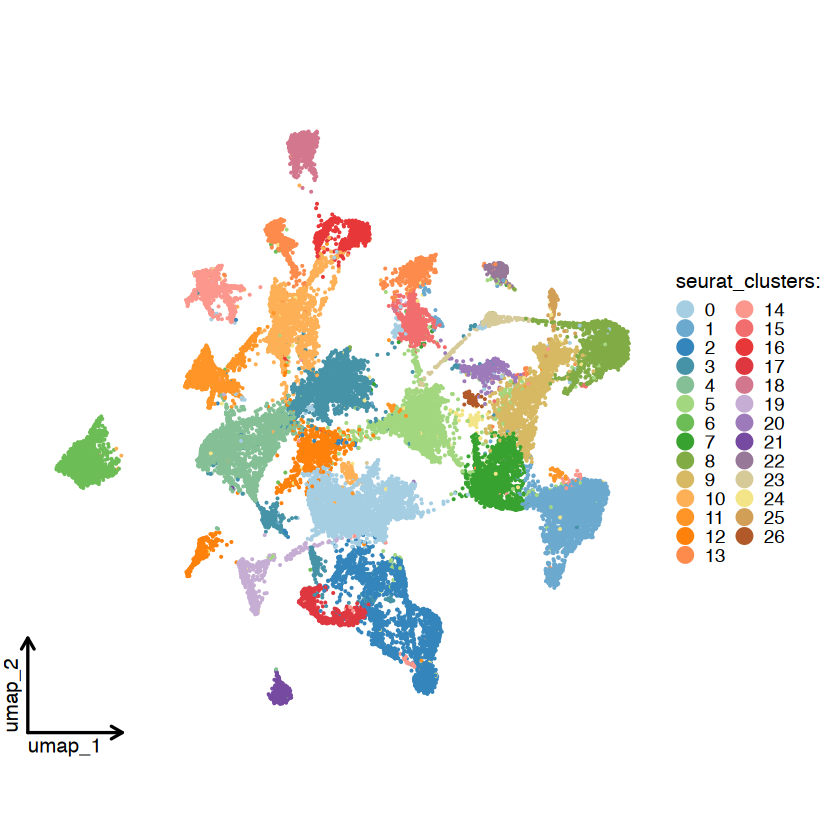

In [19]:

cluster_col="seurat_clusters"
g = CellDimPlot(
  srt = xenium.obj, 
  group.by = cluster_col, 
  reduction = "UMAP", theme_use = "theme_blank",
  raster = FALSE,
  stat_plot_size = 3
) 
g 


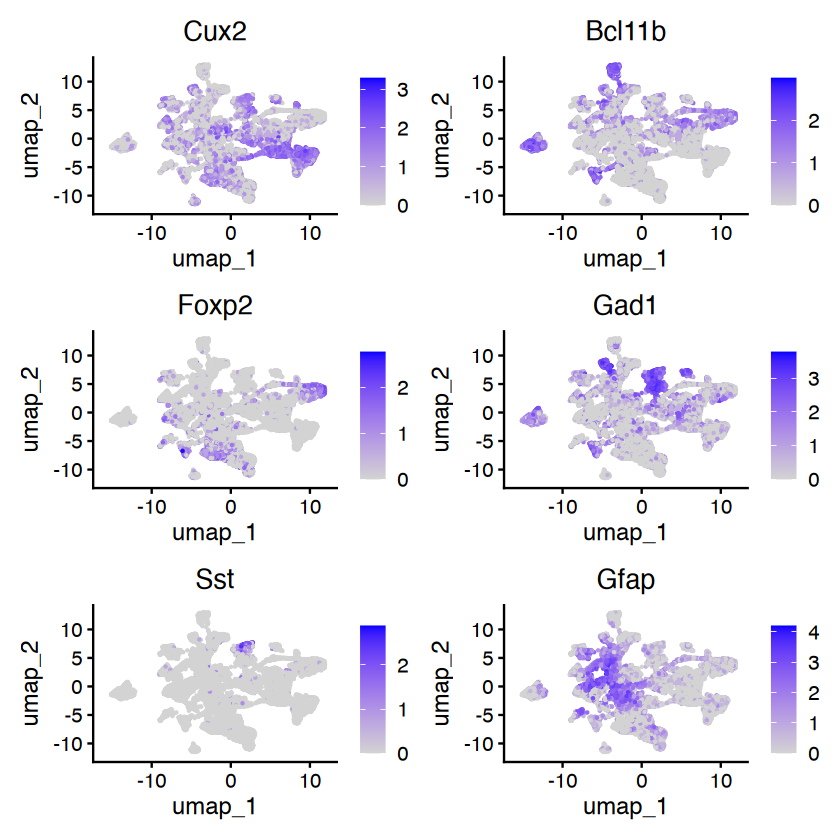

In [20]:
FeaturePlot(xenium.obj, features = c("Cux2", "Bcl11b", "Foxp2", "Gad1", "Sst", "Gfap"))

Warning message:
“No FOV associated with assay 'SCT', using global default FOV”


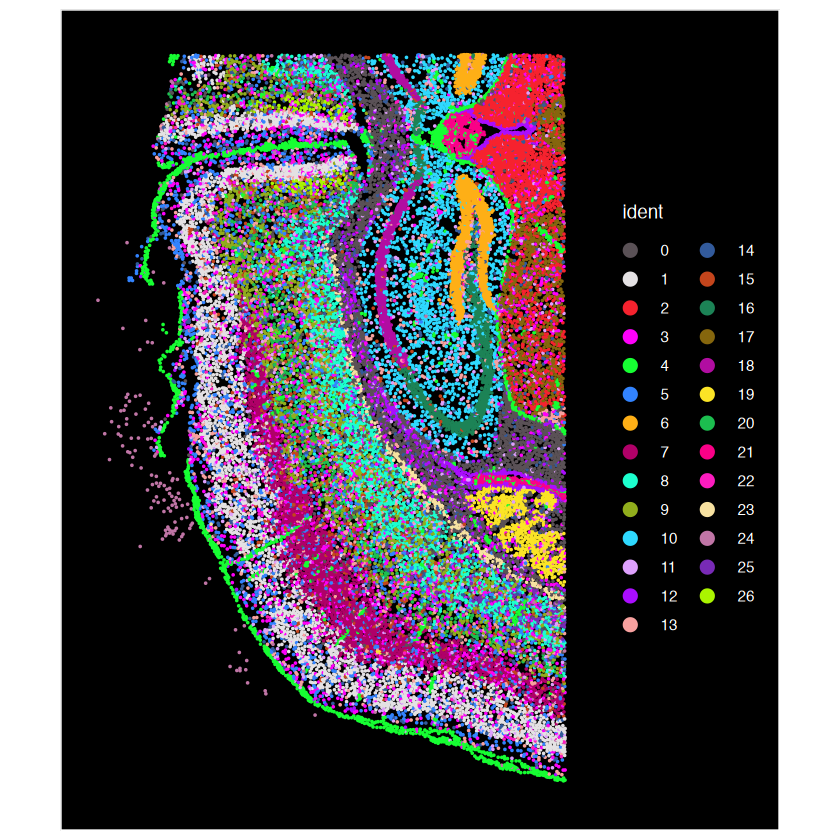

In [21]:
ImageDimPlot(xenium.obj, cols = "polychrome", 
             size = 0.75)

In [22]:
library(spacexr)

query.counts <- GetAssayData(xenium.obj, assay = "Xenium", slot = "counts")
coords <- GetTissueCoordinates(xenium.obj[["fov"]], which = "centroids")
rownames(coords) <- coords$cell
coords$cell <- NULL
query <- SpatialRNA(coords, query.counts, colSums(query.counts))

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


In [23]:
# allen.corted.ref can be downloaded here:
# https://www.dropbox.com/s/cuowvm4vrf65pvq/allen_cortex.rds?dl=1
allen.cortex.ref <- readRDS(paste0(data_dir, "/allen_cortex.rds"))
allen.cortex.ref <- UpdateSeuratObject(allen.cortex.ref)

Idents(allen.cortex.ref) <- "subclass"
# remove CR cells because there aren't enough of them for annotation
allen.cortex.ref <- subset(allen.cortex.ref, subset = subclass != "CR")
counts <- GetAssayData(allen.cortex.ref, assay = "RNA", slot = "counts")
cluster <- as.factor(allen.cortex.ref$subclass)
names(cluster) <- colnames(allen.cortex.ref)
nUMI <- allen.cortex.ref$nCount_RNA
names(nUMI) <- colnames(allen.cortex.ref)
nUMI <- colSums(counts)
levels(cluster) <- gsub("/", "-", levels(cluster))
reference <- Reference(counts, cluster, nUMI)

Validating object structure



Updating object slots



Ensuring keys are in the proper structure



Warning message:
“Assay RNA changing from Assay to Assay”


Ensuring keys are in the proper structure



Ensuring feature names don't have underscores or pipes



Updating slots in RNA



Validating object structure for Assay ‘RNA’



Object representation is consistent with the most current Seurat version



In [24]:
# run RCTD with many cores
RCTD <- create.RCTD(query, reference, max_cores = 8)
RCTD <- run.RCTD(RCTD, doublet_mode = "doublet")

Begin: process_cell_type_info



process_cell_type_info: number of cells in reference: 14242



process_cell_type_info: number of genes in reference: 34617




     Astro       Endo    L2-3 IT         L4      L5 IT      L5 PT      L6 CT 
       368         94        982       1401        880        544        960 
     L6 IT        L6b      Lamp5 Macrophage      Meis2         NP      Oligo 
      1872        358       1122         51         45        362         91 
      Peri      Pvalb   Serpinf1        SMC       Sncg        Sst        Vip 
        32       1337         27         55        125       1741       1728 
      VLMC 
        67 


End: process_cell_type_info



...

Likelihood value: 148159.897969503



Sigma value:  0.7



Likelihood value: 147678.589123498



Sigma value:  0.7



[1] "gather_results: finished 1000"
[1] "gather_results: finished 2000"
[1] "gather_results: finished 3000"
[1] "gather_results: finished 4000"
[1] "gather_results: finished 5000"
[1] "gather_results: finished 6000"
[1] "gather_results: finished 7000"
[1] "gather_results: finished 8000"
[1] "gather_results: finished 9000"
[1] "gather_results: finished 10000"
[1] "gather_results: finished 11000"
[1] "gather_results: finished 12000"
[1] "gather_results: finished 13000"
[1] "gather_results: finished 14000"
[1] "gather_results: finished 15000"
[1] "gather_results: finished 16000"
[1] "gather_results: finished 17000"
[1] "gather_results: finished 18000"
[1] "gather_results: finished 19000"
[1] "gather_results: finished 20000"
[1] "gather_results: finished 21000"
[1] "gather_results: finished 22000"
[1] "gather_results: finished 23000"
[1] "gather_results: finished 24000"
[1] "gather_results: finished 25000"
[1] "gather_results: finished 26000"
[1] "gather_results: finished 27000"
[1] "gathe

In [25]:
annotations.df <- RCTD@results$results_df
annotations <- annotations.df$first_type
names(annotations) <- rownames(annotations.df)
xenium.obj$predicted.celltype <- annotations
keep.cells <- Cells(xenium.obj)[!is.na(xenium.obj$predicted.celltype)]
xenium.obj <- subset(xenium.obj, cells = keep.cells)

Warning message:
“Not validating FOV objects”


Warning message:
“Not validating Centroids objects”


Warning message:
“Not validating Centroids objects”


Warning message:
“Not validating FOV objects”


Warning message:
“Not validating FOV objects”


Warning message:
“Not validating FOV objects”


Warning message:
“Not validating Seurat objects”


In [26]:
cluster_col="predicted.celltype"
Idents(xenium.obj) = xenium.obj@meta.data[,cluster_col]

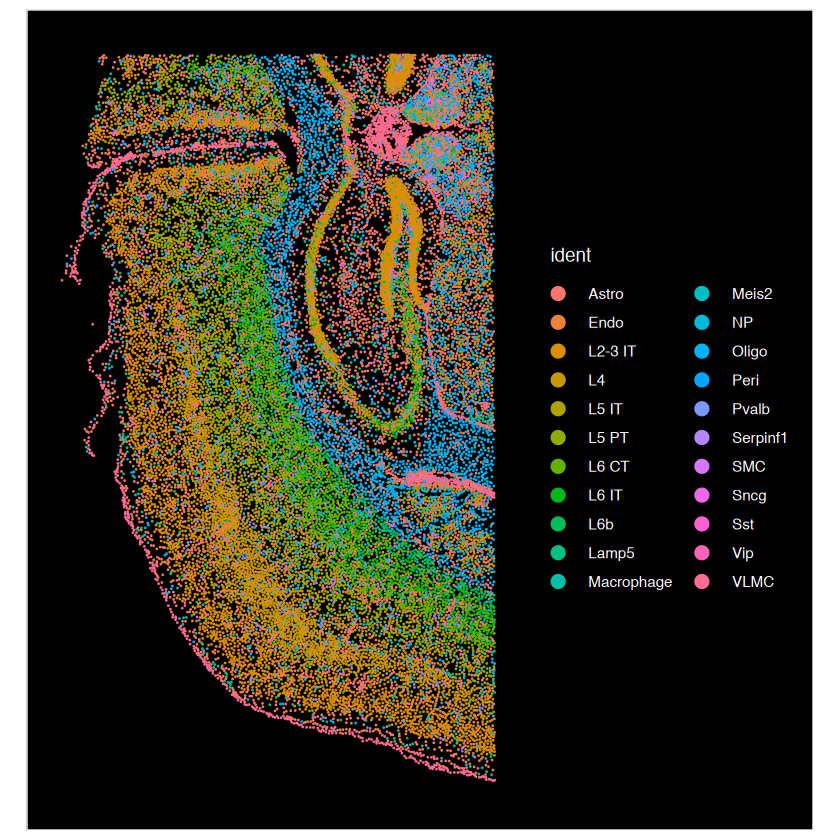

In [27]:
markers = xenium.obj.markers %>%
  group_by(cluster) %>%
  dplyr::slice_max(avg_log2FC, n = 1) %>%
  as.data.frame() %>%
  pull(gene) %>%
  unique()
marker_COLORS = manual_colors
names(marker_COLORS) = markers
  
ImageDimPlot(xenium.obj, fov = "fov", molecules = markers, nmols = 20000) &
  scale_color_manual(values = marker_COLORS) 

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


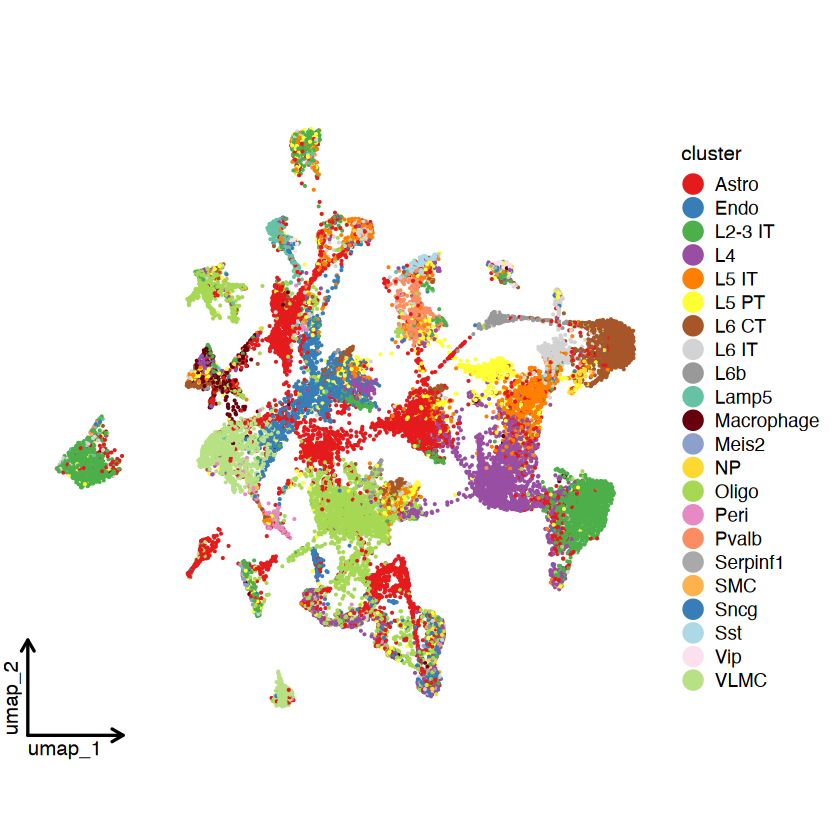

In [28]:

cluster_COLORS = manual_colors
names(cluster_COLORS) = levels(Idents(xenium.obj))
cluster_COLORS = na.omit(cluster_COLORS)
g = CellDimPlot(
  srt = xenium.obj, 
  group.by = cluster_col, 
  reduction = "UMAP", theme_use = "theme_blank",
  raster = FALSE,
  stat_plot_size = 1
) &
  scale_color_manual(values = cluster_COLORS) &
  guides(color = guide_legend(override.aes = list(size=5,
                                                 alpha = 1),
                             title = "cluster",
                             ncol = 1))
g 

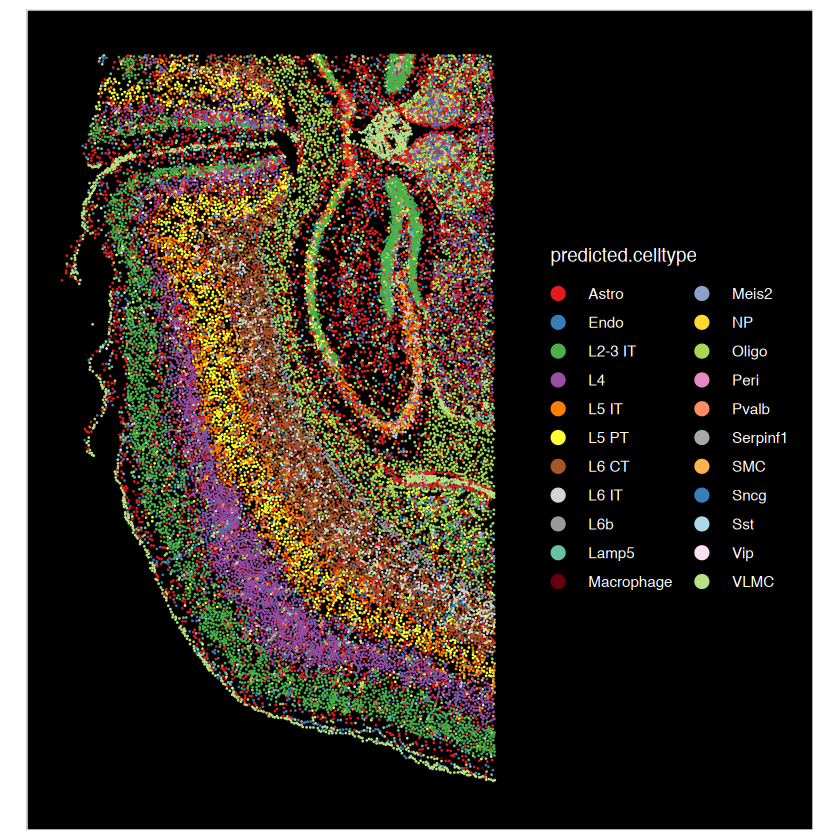

In [29]:
g = ImageDimPlot(xenium.obj,
             fov = "fov", 
             size = 0.5,
             group.by = cluster_col)  &
  scale_fill_manual(values = cluster_COLORS)
g 

## Spatial neighborhood analysis (SNA, cell type level analysis)

In [30]:
n_perm = 100
neighbors.k_ = 30 # Number of neighbors to search
seed = 1234

start_time = Sys.time()
xenium.obj <- nhood_enrichment.Seurat(
  xenium.obj,
  cluster_key = cluster_col, 
  neighbors.k = neighbors.k_, 
  connectivity_key = "nn", 
  transformation = TRUE,
  n_perms = n_perm, seed = seed, n_jobs = 4
)
end_time = Sys.time()
print("Elapsed time:")
difftime(end_time, start_time, units = "secs")

[1] "Elapsed time:"


Time difference of 7.315697 secs

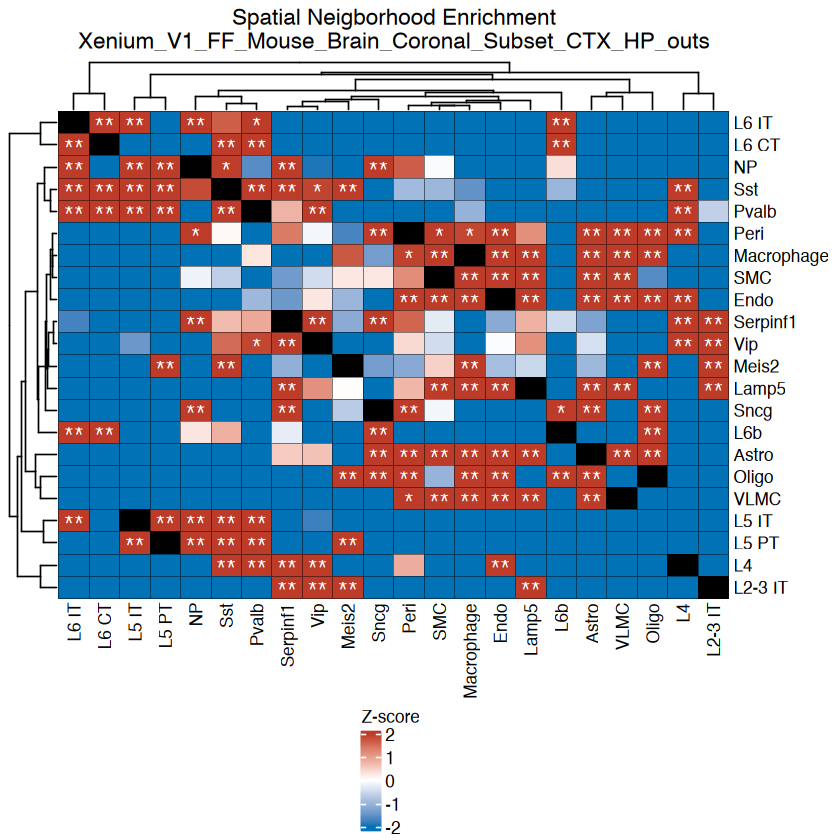

In [31]:
mat = xenium.obj@misc[[paste0(cluster_col,"_nhood_enrichment")]]$zscore
colnames(mat) = gsub("^Cluster","",colnames(mat))
rownames(mat) = gsub("^Cluster","",rownames(mat))

pval_mat <- 1 - pnorm(mat)
fdr_vec <- p.adjust(as.vector(pval_mat), method = "BH")
fdr_mat <- matrix(fdr_vec, nrow=nrow(mat), ncol=ncol(mat),
                  dimnames = dimnames(mat))
sig_mat <- ifelse(fdr_mat < 0.05, "**", ifelse(fdr_mat > 0.05 & fdr_mat < 0.1, "*", ""))

common_names <- intersect(rownames(mat), colnames(mat))
for (nm in common_names) {
  mat[nm, nm] <- NA
  sig_mat[nm, nm] <- ""
}

heatmap <- Heatmap(mat,
                   name = "Z-score",
                   col = colorRamp2(c(-2, 0, 2), c("#0072B5FF", "white", "#BC3C29FF")), 
                   show_row_names = TRUE, 
                   show_column_names = TRUE,  
                   cluster_rows = TRUE,  
                   cluster_columns = TRUE,  
                   #show_column_dend = FALSE,
                   #show_row_dend = FALSE,
                   row_title = "",  
                   column_title = paste0("Spatial Neigborhood Enrichment\n",data_name),
                   rect_gp = gpar(col = "black", lwd = 0.3),
                   na_col = "black",          
                   column_names_gp = grid::gpar(fontsize = 10),
                   row_names_gp = grid::gpar(fontsize = 10),
                   cell_fun = function(j, i, x, y, width, height, fill) {
                     if(sig_mat[i, j] == "**") {
                       grid.text("**", 
                                 x = x,
                                 y = y - 0.2 * height,  
                                 gp = gpar(fontsize = 15, col = "white", fontface = "bold"))
                     }
                     if(sig_mat[i, j] == "*") {
                       grid.text("*", 
                                 x = x,
                                 y = y - 0.2 * height, 
                                 gp = gpar(fontsize = 15, col = "white", fontface = "bold"))
                     }
                   }
)

draw(heatmap, 
     merge_legend = TRUE,
     heatmap_legend_side = "bottom", 
     annotation_legend_side = "bottom")


## Spatial co-localization score (sCLA, cell-cell level analysis)

In [32]:

cluster_x <- "L6 IT"
cluster_y <- "L6 CT"
table(Idents(xenium.obj))
radius_ = 30 # Radius to search for neighbors (µm, cell_type_2) around anchor cells (cell_type_1)

start_time = Sys.time()
cooccur_local_df <- cooccur_local.Seurat(
  xenium.obj,
  cluster_key      = cluster_col,
  sample_key       = "fov",
  cluster_x        = cluster_x,
  cluster_y        = cluster_y,
  connectivity_key = "nn",
  neighbors.k      = neighbors.k_, 
  radius           = radius_,
  maxnsteps        = 15
)
end_time = Sys.time()
print("Elapsed time:")
difftime(end_time, start_time, units = "secs")


colnames(cooccur_local_df) = gsub(" ", "_", colnames(cooccur_local_df))
summary(cooccur_local_df)


     Astro       Endo    L2-3 IT         L4      L5 IT      L5 PT      L6 CT 
      5468       1773       4563       3679       1863       1896       2182 
     L6 IT        L6b      Lamp5 Macrophage      Meis2         NP      Oligo 
      1114        355        521        448         82        277       3892 
      Peri      Pvalb   Serpinf1        SMC       Sncg        Sst        Vip 
       239        604         56         24        351        223        114 
      VLMC 
      1417 

stopping after 4 steps



[1] "Elapsed time:"


Time difference of 6.518088 secs

 cooccur_local_L6_IT_L6_CT
 Min.   :0.00000          
 1st Qu.:0.00000          
 Median :0.00000          
 Mean   :0.09290          
 3rd Qu.:0.03948          
 Max.   :1.20254          

Warning message:
“No FOV associated with assay 'SCT', using global default FOV”


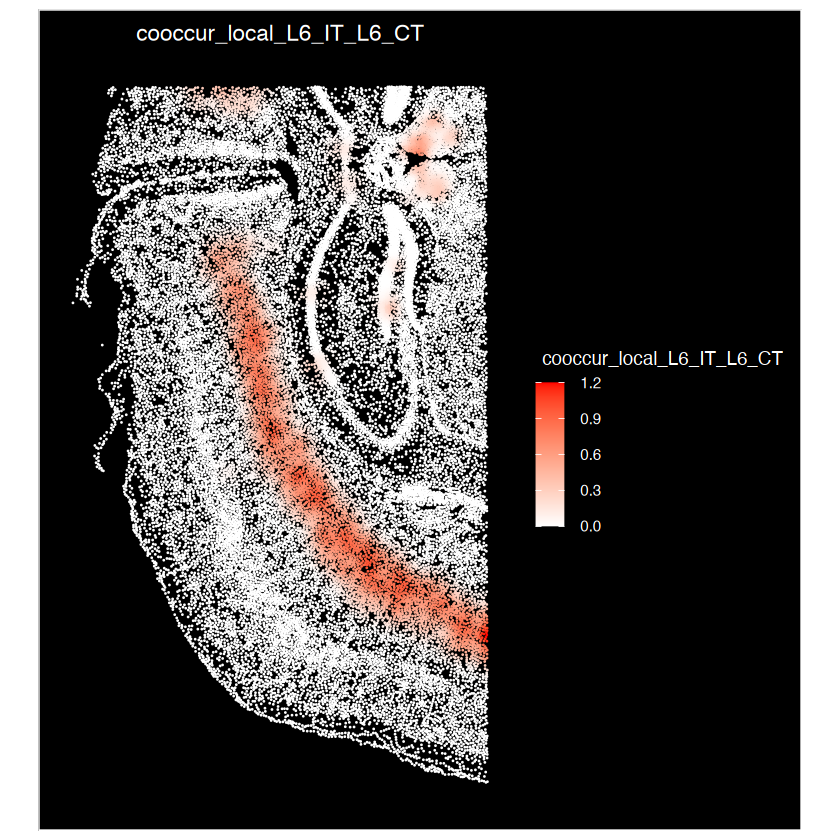

In [33]:
xenium.obj = AddMetaData(xenium.obj, cooccur_local_df)

g = ImageFeaturePlot(xenium.obj, 
                     features = gsub(" ", "_", paste0("cooccur_local_",cluster_x,"_",cluster_y)), 
                     #dark.background = F,
                     cols = c("white", "red"))
g

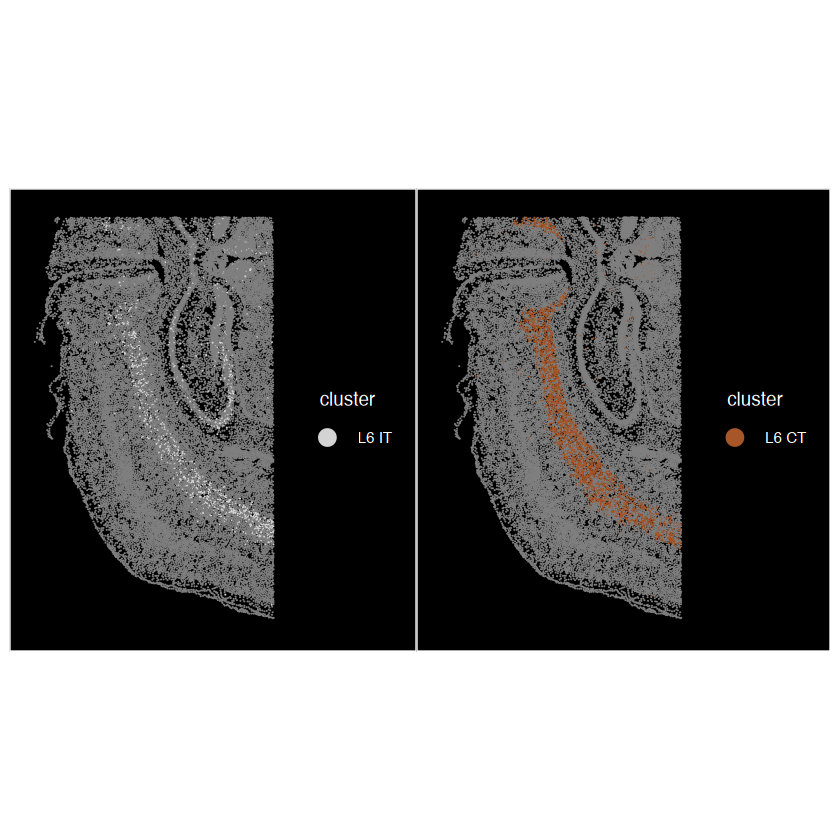

In [34]:

cluster_COLORS_ = cluster_COLORS[cluster_x]
g_x = ImageDimPlot(xenium.obj,
             fov = "fov", 
             size = 0.3,
             group.by = cluster_col)  &
  scale_fill_manual(values = cluster_COLORS_) &
  guides(fill = guide_legend(override.aes = list(size=5,
                                                 alpha = 1),
                             title = "cluster",
                             ncol = 1))
cluster_COLORS_ = cluster_COLORS[cluster_y]
g_y = ImageDimPlot(xenium.obj,
             fov = "fov", 
             size = 0.3,
             group.by = cluster_col)  &
  scale_fill_manual(values = cluster_COLORS_) &
  guides(fill = guide_legend(override.aes = list(size=5,
                                                 alpha = 1),
                             title = "cluster",
                             ncol = 1))
g_x + g_y

In [35]:
sessionInfo()

R version 4.3.2 (2023-10-31)
Platform: aarch64-apple-darwin20 (64-bit)
Running under: macOS 26.3.1

Matrix products: default
BLAS:   /Library/Frameworks/R.framework/Versions/4.3-arm64/Resources/lib/libRblas.0.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.3-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.11.0

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

time zone: Asia/Tokyo
tzcode source: internal

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] spacexr_2.2.1         spatialCooccur_0.99.2 testthat_3.2.1       
 [4] ComplexHeatmap_2.18.0 circlize_0.4.15       ggplot2_3.4.4        
 [7] SCP_0.5.6             dplyr_1.1.4           magrittr_2.0.3       
[10] Seurat_5.2.1          SeuratObject_5.0.2    sp_2.1-2             

loaded via a namespace (and not attached):
  [1] IRanges_2.36.0                R.methodsS3_1.8.2            
  [3] progress_